<div style="background: linear-gradient(120deg, #1a3a5c 0%, #2d6a9f 60%, #4a9eda 100%); padding: 28px 36px; border-radius: 14px; display: flex; align-items: center; gap: 28px; box-shadow: 0 4px 18px rgba(0,0,0,0.18);">
    <img src='Figures/iteso.jpg' style="height: 110px; border-radius: 8px; background: white; padding: 6px; flex-shrink: 0; box-shadow: 0 2px 8px rgba(0,0,0,0.2);"/>
    <div style="border-left: 2px solid rgba(255,255,255,0.4); padding-left: 28px;">
        <h1 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Ingeniería y Ciencia de Datos</h1>
        <h3 style="margin: 0 0 8px 0; color: white; font-size: 1.5em; line-height: 1.3;">Laboratorio de Procesamiento de Datos</h3>
        <h3 style="margin: 0; color: rgba(255,255,255,0.8); font-weight: normal; font-size: 1.05em;">Módulo 1: Repaso general del Modulo I</h3>
    </div>
</div>



**Yair Santiago Robles Zamora**


## Ejercicio 1: Extracción multi‑fuente

**Texto plano: `niebla_unamuno.txt`**

El archivo es la novela *Niebla* descargada de Project Gutenberg. Incluye un encabezado y un pie de licencia en inglés que **no** forman parte de la obra.

1. Lee el archivo con `open(..., encoding="utf-8")` dentro de un `with`. Conserva **solo** el texto entre las marcas `*** START OF ...` y `*** END OF ...`. Reporta el número de caracteres y de líneas antes y después del recorte.
2. Los capítulos inician con una línea que contiene solo un número romano (`I`, `II`, …). Cuenta cuántos capítulos tiene la novela.
3. Normaliza el texto (minúsculas, solo letras incluyendo acentos y `ñ`) con un patron ('[a-záéíóúüñ]+') y construye un `DataFrame` con las **15 palabras más frecuentes** de longitud ≥ 5. ¿Cuántas veces aparecen `augusto` y `eugenia`?
4. Guarda el resultado como CSV en una carpeta `salida` en la carpeta `Data`.


In [1]:
from pathlib import Path
import json
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

In [6]:
ruta = Path("Data/Datos_repaso")
archivo = ruta / "niebla_unamuno.txt"
texto = archivo.read_text(encoding="utf-8")


In [7]:
inicio = texto.find("*** START OF")
fin = texto.find("*** END OF")

print("Inicio:", inicio)
print("Fin:", fin)

texto_delim = texto[inicio:fin]
print("Largo og:",len(texto))
print("Largo recortado:", len(texto_delim))
print("Caracteres recortadas:", len(texto)-len(texto_delim))

Inicio: 998
Fin: 320742
Largo og: 339189
Largo recortado: 319744
Caracteres recortadas: 19445


In [10]:

lineas_texto=texto_delim.splitlines()
lineas_texto
contador = 0
for linea in lineas_texto:
    linea_limpia = linea.strip()

    if linea_limpia:
        contador +=1
print("Lineas delimitadas:",contador)

Lineas delimitadas: 5896


In [11]:
lineas_antes=texto.splitlines()
lineas_antes
contador2 = 0
for linea in lineas_antes:
    linea_limpia_og = linea.strip()

    if linea_limpia_og:
        contador2 +=1
print("Lineas og:",contador2)

Lineas og: 6208


In [13]:
capitulos = re.findall(r"(?m)^[ \t]*[IVXLCDM]+[ \t]*$", texto_delim)
print("Número de capítulos:", len(capitulos))

Número de capítulos: 33


In [14]:
patron_acentos = '[a-záéíóúüñA]+'
palabras_novela = re.findall(patron_acentos, texto.lower())
palabras_novela

['the',
 'project',
 'gutenberg',
 'ebook',
 'of',
 'niebla',
 'nivola',
 'this',
 'ebook',
 'is',
 'for',
 'the',
 'use',
 'of',
 'anyone',
 'anywhere',
 'in',
 'the',
 'united',
 'states',
 'and',
 'most',
 'other',
 'parts',
 'of',
 'the',
 'world',
 'at',
 'no',
 'cost',
 'and',
 'with',
 'almost',
 'no',
 'restrictions',
 'whatsoever',
 'you',
 'may',
 'copy',
 'it',
 'give',
 'it',
 'away',
 'or',
 're',
 'use',
 'it',
 'under',
 'the',
 'terms',
 'of',
 'the',
 'project',
 'gutenberg',
 'license',
 'included',
 'with',
 'this',
 'ebook',
 'or',
 'online',
 'at',
 'www',
 'gutenberg',
 'org',
 'if',
 'you',
 'are',
 'not',
 'located',
 'in',
 'the',
 'united',
 'states',
 'you',
 'will',
 'have',
 'to',
 'check',
 'the',
 'laws',
 'of',
 'the',
 'country',
 'where',
 'you',
 'are',
 'located',
 'before',
 'using',
 'this',
 'ebook',
 'title',
 'niebla',
 'nivola',
 'author',
 'miguel',
 'de',
 'unamuno',
 'release',
 'date',
 'august',
 'ebook',
 'most',
 'recently',
 'updated',


In [17]:
palabras_grandes = [p for p in palabras_novela]
conteo_palabras = Counter(palabras_grandes)
conteo_palabras.most_common()

[('de', 2528),
 ('que', 2479),
 ('y', 2228),
 ('no', 1551),
 ('la', 1548),
 ('a', 1535),
 ('el', 969),
 ('en', 951),
 ('es', 880),
 ('se', 862),
 ('lo', 686),
 ('me', 627),
 ('le', 571),
 ('un', 555),
 ('su', 445),
 ('por', 441),
 ('con', 432),
 ('una', 427),
 ('pero', 418),
 ('los', 409),
 ('más', 395),
 ('qué', 392),
 ('como', 380),
 ('usted', 376),
 ('augusto', 372),
 ('yo', 368),
 ('al', 338),
 ('si', 334),
 ('mi', 306),
 ('sí', 303),
 ('las', 294),
 ('para', 272),
 ('del', 247),
 ('te', 236),
 ('eugenia', 233),
 ('eso', 229),
 ('o', 219),
 ('ha', 218),
 ('pues', 215),
 ('don', 206),
 ('ya', 203),
 ('the', 190),
 ('ella', 190),
 ('mujer', 188),
 ('él', 184),
 ('todo', 174),
 ('así', 167),
 ('hombre', 150),
 ('ni', 149),
 ('tú', 141),
 ('bien', 138),
 ('he', 137),
 ('sin', 136),
 ('dijo', 136),
 ('ahora', 136),
 ('cuando', 132),
 ('esto', 132),
 ('sus', 130),
 ('casa', 130),
 ('hay', 125),
 ('otro', 124),
 ('of', 122),
 ('sino', 119),
 ('porque', 113),
 ('nos', 112),
 ('mí', 110),
 

In [20]:
top_palabras = pd.DataFrame(conteo_palabras.most_common(), columns = ['palabra', 'frecuencia'])
top_palabras.head(15)


,palabra,frecuencia
0,de,2528
1,que,2479
2,y,2228
3,no,1551
4,la,1548
5,a,1535
6,el,969
7,en,951
8,es,880
9,se,862


In [26]:
conteo_palabras['augusto'], conteo_palabras['eugenia']

(372, 233)

In [24]:

top_palabras.to_csv(os.path.join(ruta, "top_palabras_niebla.csv"), index = False)
pd.read_csv(os.path.join(ruta, "top_palabras_niebla.csv"))

,palabra,frecuencia
0,de,2528
1,que,2479
2,y,2228
3,no,1551
4,la,1548
...,...,...
8171,facility,1
8172,includes,1
8173,subscribe,1
8174,newsletter,1


##  Ejercicio 2: Clasificación de tipos de datos

Usa `taxis_nyc.csv` (viajes de taxi en Nueva York, marzo de 2019).

1. Carga el archivo. Muestra `shape`, `dtypes` y `nunique()`. Separa las columnas en `numericas` y `no_numericas` con `select_dtypes`.
2. Clasifica los tipos de variables en una tabla: `pickup`, `passengers`, `distance`, `fare`, `tip`, `tolls`, `color`, `payment`, `pickup_zone`, `pickup_borough` y la variable derivada `duracion_min = (dropoff - pickup)` en minutos.
3. ¿Hay viajes con **0 pasajeros**, `distance == 0` o `duracion_min <= 0`?
4. Crea una columna `es_amarillo` (1/0) y `pago_tarjeta` (1/0).



In [29]:
ruta=os.getcwd()
datosnyc=os.path.join(ruta,"Data")
archivo_path=os.path.join(datosnyc,"Datos_repaso")
archivo_path

'c:\\Laboratorio_de_Procesamiento_de_Datos_02026\\Modulo I\\Data\\Datos_repaso'

In [35]:
taxis = pd.read_csv(os.path.join(archivo_path, "taxis_nyc.csv"), parse_dates=["pickup", "dropoff"])
print(taxis.shape)


(6433, 14)


In [ ]:
print(taxis.dtypes)

pickup             datetime64[ns]
dropoff            datetime64[ns]
passengers                  int64
distance                  float64
fare                      float64
tip                       float64
tolls                     float64
total                     float64
color                      object
payment                    object
pickup_zone                object
dropoff_zone               object
pickup_borough             object
dropoff_borough            object
dtype: object


In [41]:
taxis.nunique()

pickup             6414
dropoff            6425
passengers            7
distance           1079
fare                220
tip                 489
tolls                16
total               898
color                 2
payment               2
pickup_zone         194
dropoff_zone        203
pickup_borough        4
dropoff_borough       5
dtype: int64

In [44]:
numericas=taxis.select_dtypes(include="number")
numericas

,passengers,distance,fare,tip,tolls,total
0,1,1.60,7.0,2.15,0.0,12.95
1,1,0.79,5.0,0.00,0.0,9.30
2,1,1.37,7.5,2.36,0.0,14.16
3,1,7.70,27.0,6.15,0.0,36.95
4,3,2.16,9.0,1.10,0.0,13.40
...,...,...,...,...,...,...
6428,1,0.75,4.5,1.06,0.0,6.36
6429,1,18.74,58.0,0.00,0.0,58.80
6430,1,4.14,16.0,0.00,0.0,17.30
6431,1,1.12,6.0,0.00,0.0,6.80


In [43]:

no_num=taxis.select_dtypes(exclude="number")
no_num

,pickup,dropoff,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [ ]:
taxis["duracion_min"] = (
    taxis["dropoff"] - taxis["pickup"]
).dt.total_seconds() / 60
taxis

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough,duracion_min
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan,6.250000
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan,7.083333
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan,7.400000
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan,25.866667
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan,9.533333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan,3.566667
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx,56.383333
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn,19.116667
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn,5.066667


In [52]:
numericas_discretas=taxis['passengers']
pd.DataFrame(numericas_discretas)

,passengers
0,1
1,1
2,1
3,1
4,3
...,...
6428,1
6429,1
6430,1
6431,1


In [60]:
numericas_continuas=numericas[numericas.columns.difference(['passengers'])]
pd.DataFrame(numericas_continuas)

,distance,fare,tip,tolls,total
0,1.60,7.0,2.15,0.0,12.95
1,0.79,5.0,0.00,0.0,9.30
2,1.37,7.5,2.36,0.0,14.16
3,7.70,27.0,6.15,0.0,36.95
4,2.16,9.0,1.10,0.0,13.40
...,...,...,...,...,...
6428,0.75,4.5,1.06,0.0,6.36
6429,18.74,58.0,0.00,0.0,58.80
6430,4.14,16.0,0.00,0.0,17.30
6431,1.12,6.0,0.00,0.0,6.80


In [71]:
cualitativas_binarias=no_num[no_num.columns.difference(['pickup', 'dropoff', 'pickup_zone', 'dropoff_zone','pickup_borough', 'dropoff_borough'])]
cualitativas_binarias

,color,payment
0,yellow,credit card
1,yellow,cash
2,yellow,credit card
3,yellow,credit card
4,yellow,credit card
...,...,...
6428,green,credit card
6429,green,credit card
6430,green,cash
6431,green,credit card


In [72]:
cualitativas_nominales=no_num[no_num.columns.difference(['color','payment'])]
cualitativas_nominales

,dropoff,dropoff_borough,dropoff_zone,pickup,pickup_borough,pickup_zone
0,2019-03-23 20:27:24,Manhattan,UN/Turtle Bay South,2019-03-23 20:21:09,Manhattan,Lenox Hill West
1,2019-03-04 16:19:00,Manhattan,Upper West Side South,2019-03-04 16:11:55,Manhattan,Upper West Side South
2,2019-03-27 18:00:25,Manhattan,West Village,2019-03-27 17:53:01,Manhattan,Alphabet City
3,2019-03-10 01:49:51,Manhattan,Yorkville West,2019-03-10 01:23:59,Manhattan,Hudson Sq
4,2019-03-30 13:37:14,Manhattan,Yorkville West,2019-03-30 13:27:42,Manhattan,Midtown East
...,...,...,...,...,...,...
6428,2019-03-31 09:55:27,Manhattan,Central Harlem North,2019-03-31 09:51:53,Manhattan,East Harlem North
6429,2019-03-31 18:34:23,Bronx,East Concourse/Concourse Village,2019-03-31 17:38:00,Queens,Jamaica
6430,2019-03-23 23:14:25,Brooklyn,Bushwick North,2019-03-23 22:55:18,Brooklyn,Crown Heights North
6431,2019-03-04 10:14:29,Brooklyn,East Flatbush/Remsen Village,2019-03-04 10:09:25,Brooklyn,East New York


In [78]:
discretas = ['passengers']
continuas = list(numericas_continuas.columns)
binarias = list(cualitativas_binarias.columns)
nominales = list(cualitativas_nominales.columns)

filas = []

for col in discretas:
    filas.append([col, 'Discreta'])
for col in continuas:
    filas.append([col, 'Continua'])
for col in binarias:
    filas.append([col, 'Binaria'])
for col in nominales:
    filas.append([col, 'Nominal'])

clasificaciones = pd.DataFrame(filas, columns=['variables', 'clasificación'])
clasificaciones

,variables,clasificación
0,passengers,Discreta
1,distance,Continua
2,fare,Continua
3,tip,Continua
4,tolls,Continua
5,total,Continua
6,color,Binaria
7,payment,Binaria
8,dropoff,Nominal
9,dropoff_borough,Nominal


In [74]:
print("Viajes con 0 pasajeros:", (taxis["passengers"] == 0).sum())
print("Viajes con distancia 0:", (taxis["distance"] == 0).sum())
print("Viajes con duración <= 0 min:", (taxis["duracion_min"] <= 0).sum())

Viajes con 0 pasajeros: 96
Viajes con distancia 0: 51
Viajes con duración <= 0 min: 6


In [76]:
taxis["es_amarillo"] = taxis["color"].eq("yellow").astype(int)
taxis["pago_tarjeta"] = taxis["payment"].eq("credit card").astype(int)

taxis[["color", "es_amarillo", "payment", "pago_tarjeta"]].head()

,color,es_amarillo,payment,pago_tarjeta
0,yellow,1,credit card,1
1,yellow,1,cash,0
2,yellow,1,credit card,1
3,yellow,1,credit card,1
4,yellow,1,credit card,1



## Ejercicio 3: Datos faltantes y atípicos

Usa `co2_owid.csv`: emisiones de CO₂, CO₂ per cápita, población y PIB por país y año desde 1950.

**Faltantes**

1. Calcula conteo y % de faltantes por columna.
2. Filtra los renglones donde `iso_code` es faltante y revisa `country`. ¿Qué puedes cocnluir de este análisis?

**Atípicos**

3. Para **2020**, detecta atípicos de `co2_per_capita` con IQR. Lista los países y muestra un boxplot.

In [79]:
ruta=os.getcwd()
datosco2=os.path.join(ruta,"Data")
rutaco2=os.path.join(datosco2,"Datos_repaso")
rutaco2
co2 = pd.read_csv(os.path.join(rutaco2, "co2_owid.csv"))
display(pd.DataFrame({"faltantes": co2.isna().sum(), "%": (co2.isna().mean() * 100).round(2)}))


,faltantes,%
country,0,0.00
year,0,0.00
iso_code,2634,13.87
population,1809,9.53
gdp,7512,39.57
co2,1437,7.57
co2_per_capita,2491,13.12


##### (1pto para Modulo I antes de terminar el día) 
###### enviar a: gdesirena@iteso.mx

In [ ]:
no_iso=co2[co2['iso_code'].isna()]
no_iso['country'].value_counts()

country
Africa                                      75
Africa (GCP)                                75
Asia                                        75
Asia (GCP)                                  75
Asia (excl. China and India)                75
Central America (GCP)                       75
Europe                                      75
Europe (GCP)                                75
Europe (excl. EU-27)                        75
Europe (excl. EU-28)                        75
European Union (27)                         75
European Union (28)                         75
High-income countries                       75
International aviation                      75
International shipping                      75
Kosovo                                      75
Kuwaiti Oil Fires                           75
Least developed countries (Jones et al.)    75
Low-income countries                        75
Lower-middle-income countries               75
Oceania                                     75
Middl

In [86]:
no_iso["country"].unique()

array(['Africa', 'Africa (GCP)', 'Asia', 'Asia (GCP)',
       'Asia (excl. China and India)', 'Central America (GCP)', 'Europe',
       'Europe (GCP)', 'Europe (excl. EU-27)', 'Europe (excl. EU-28)',
       'European Union (27)', 'European Union (28)',
       'High-income countries', 'International aviation',
       'International shipping', 'Kosovo', 'Kuwaiti Oil Fires',
       'Kuwaiti Oil Fires (GCP)',
       'Least developed countries (Jones et al.)', 'Low-income countries',
       'Lower-middle-income countries', 'Middle East (GCP)',
       'Non-OECD (GCP)', 'North America', 'North America (GCP)',
       'North America (excl. USA)', 'OECD (GCP)', 'OECD (Jones et al.)',
       'Oceania', 'Oceania (GCP)', 'Ryukyu Islands',
       'Ryukyu Islands (GCP)', 'South America', 'South America (GCP)',
       'Upper-middle-income countries', 'World'], dtype=object)

Creo que se puede concluir que la mayoria de los que les faltan el iso code no son paises sino mas bien continentes o territorios agregados como `'European Union (27)'`, `'European Union (28)'`,`'High-income countries'`, `'International aviation'` 

,country,co2_per_capita
14127,Qatar,36.145
1570,Bahrain,25.238
2695,Brunei,24.937
17329,Trinidad and Tobago,23.661
17929,United Arab Emirates,22.783
15154,Saudi Arabia,21.089
8995,Kuwait,20.477
12027,New Caledonia,17.978
15604,Sint Maarten (Dutch part),15.897
13302,Oman,15.886


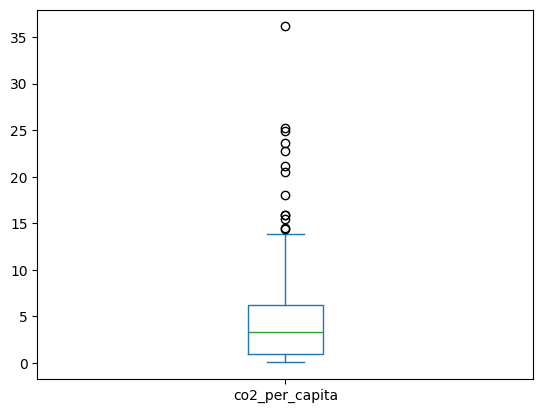

In [ ]:
co2_2020 = co2.loc[co2["year"] == 2020, ["country", "co2_per_capita"]].dropna()

q1 = co2_2020["co2_per_capita"].quantile(0.25)
q3 = co2_2020["co2_per_capita"].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

atipicos = co2_2020[(co2_2020["co2_per_capita"] < limite_inferior)|(co2_2020["co2_per_capita"] > limite_superior)]
display(atipicos.sort_values("co2_per_capita", ascending=False))

co2_2020["co2_per_capita"].plot.box()
plt.show()